In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset

house_price_data = pd.read_csv("HousePricePrediction.csv")
house_price_data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [3]:
#Collect basic info

house_price_data.shape
house_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [4]:
#Data Cleaning & Pre-processing

In [5]:
#Check for missing values

missing = pd.DataFrame({
    "missing_count": house_price_data.isnull().sum(),
    "missing_%": (house_price_data.isnull().sum()/len(house_price_data))*100
})

missing_val = missing[missing["missing_count"]>0]

print("No missing values found!") if missing_val.empty else missing_val

,missing_count,missing_%
MSZoning,4,0.137033
Exterior1st,1,0.034258
BsmtFinSF2,1,0.034258
TotalBsmtSF,1,0.034258
SalePrice,1459,49.982871


In [6]:
#Check for duplicate values

duplicates = house_price_data.duplicated().sum()

if duplicates > 0:
    duplicate_rows = pd.DataFrame(house_price_data[house_price_data.duplicated()])
    print(duplicate_rows)
else:
    print("No duplicates found!")

No duplicates found!


In [7]:
#Check data inconsistency/ data type

house_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [8]:
#Check unique values in categorical columns

for col in house_price_data.select_dtypes(include="object"):
    print("*"*125)
    print(f"Column: {col}")
    print(f"Total Unique values: {house_price_data[col].nunique()}")
    print(house_price_data[col].value_counts())

*****************************************************************************************************************************
Column: MSZoning
Total Unique values: 5
MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64
*****************************************************************************************************************************
Column: LotConfig
Total Unique values: 5
LotConfig
Inside     2133
Corner      511
CulDSac     176
FR2          85
FR3          14
Name: count, dtype: int64
*****************************************************************************************************************************
Column: BldgType
Total Unique values: 5
BldgType
1Fam      2425
TwnhsE     227
Duplex     109
Twnhs       96
2fmCon      62
Name: count, dtype: int64
*****************************************************************************************************************************
Column: Exterior1st
Total Unique v

In [9]:
#Fix column names and coumn data

house_price_data.columns = house_price_data.columns.str.strip()

for col in house_price_data.select_dtypes(include="object"):
    house_price_data[col] = house_price_data[col].str.strip()

print("Avg. House Price:", house_price_data["SalePrice"].mean())

Avg. House Price: 180921.19589041095


In [10]:
#Data Restructuring

#Drop Id col as it's of no use in model training
house_price_data.drop(["Id"], axis=1, inplace=True) 

#Replace null Sale prices with mean Sale prices
house_price_data["SalePrice"] = house_price_data["SalePrice"].fillna(house_price_data["SalePrice"].mean())

#Drop rows/records with null values
house_price_data = house_price_data.dropna()

In [11]:
#Final Check
house_price_data.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [12]:
#Data Encoding

cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
house_price_data = pd.get_dummies(house_price_data, columns=cols, drop_first=True)

In [13]:
#Model Training

In [14]:
#Train Test Split
from sklearn.model_selection import train_test_split

X = house_price_data.drop(columns=["SalePrice"])
y = house_price_data["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [15]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1453,20,17217,5,2006,2006,0.0,1140.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2021,20,19508,5,1974,1974,0.0,1430.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
188,90,7018,5,1979,1979,0.0,1086.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1273,80,11512,7,1959,2006,0.0,1019.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1960,20,7560,5,1971,1971,613.0,864.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [16]:
#Model Training
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
#Predicting values
y_pred = model.predict(X_test)

In [18]:
#Evaluation Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

R2 Score: 0.37414217961383156
MAE: 30829.93666432242
RMSE: 41138.558702301765
0.18742025463428386


In [19]:
# Feature Scaling - to try & improve baseline performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
#Model training

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
#Predicting values
y_pred = model.predict(X_test_scaled)

In [22]:
#Evaluation Metrics

print("R2 Score:", r2_score(y_test, y_pred)) #Very less accuracy

print("MAE:", mean_absolute_error(y_test, y_pred)) #On average, your predictions are off by about $30,830/-
#Avg. House Price: $180,922/-, but the predictions are about ±30,830

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) #RMSE penalizes large mistakes more heavily than MAE
# Model is making some large prediction errors on certain houses
# RMSE > MAE
# 41139 > 30830

print(mean_absolute_percentage_error(y_test, y_pred)) #18.74% error

R2 Score: 0.3741421796138532
MAE: 30829.93666432187
RMSE: 41138.55870230105
0.18742025463427797


In [23]:
#Recommendations
# To get better results we can try some other regression model 
# We can also use techniques like Bagging & Boosting

In [24]:
#EDA

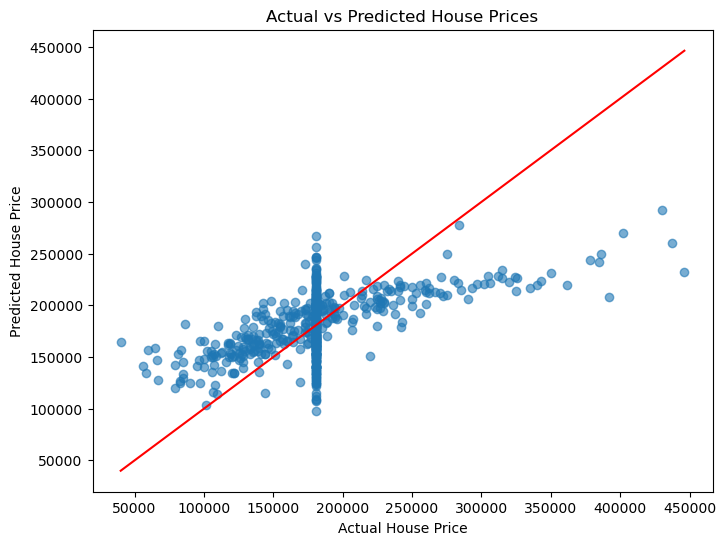

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r-'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()